INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
Pearson Correlation: -0.2343
Spearman Correlation: -0.2834


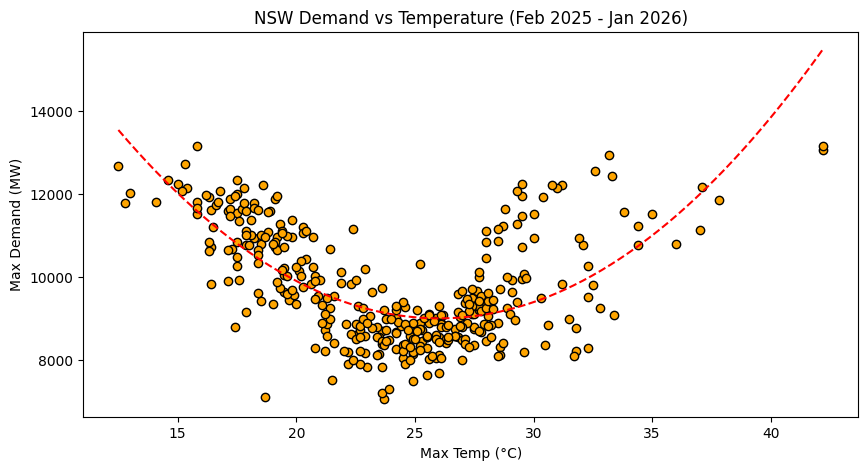

In [ ]:
# ============================================================
# NSW Electricity Demand vs Temperature Analysis (Feb 2025 - Jan 2026)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from nemosis import dynamic_data_compiler

# ============================================================
# 1. PULL DEMAND DATA VIA NEMOSIS
# ============================================================

folder = r'C:\Users\kevin\OneDrive\Desktop\raw_aemo_data'

data = dynamic_data_compiler(
    start_time='2025/02/01 00:00:00',
    end_time='2026/02/01 00:00:00',
    table_name='DISPATCHREGIONSUM',
    raw_data_location=folder
)

# ============================================================
# 2. CLEAN DEMAND DATA
# ============================================================

nsw_df = data[data['REGIONID'] == 'NSW1'].copy()
nsw_df['SETTLEMENTDATE'] = pd.to_datetime(nsw_df['SETTLEMENTDATE'])

daily_demand = nsw_df.groupby(nsw_df['SETTLEMENTDATE'].dt.date)['TOTALDEMAND'].max().reset_index()
daily_demand.columns = ['Date', 'Max_Demand']
daily_demand['Date'] = pd.to_datetime(daily_demand['Date'])

# ============================================================
# 3. LOAD & CLEAN TEMPERATURE DATA
# ============================================================

import glob

temp_files = glob.glob(folder + r'\Sydney_Temp_*.csv')

temp_dfs = []
for file in temp_files:
    df = pd.read_csv(file, skiprows=9, encoding='latin1')
    temp_dfs.append(df)

temp_combined = pd.concat(temp_dfs, ignore_index=True)
temp_combined['Date'] = pd.to_datetime(temp_combined['Date'])
temp_combined = temp_combined.dropna(subset=['Date'])
temp_clean = temp_combined[['Date', 'Maximum temperature (°C)']].copy()
temp_clean.columns = ['Date', 'Max_Temp']

# ============================================================
# 4. MERGE DATASETS
# ============================================================

final_df = pd.merge(daily_demand, temp_clean, on='Date', how='inner')
final_df['Month'] = final_df['Date'].dt.month_name()
final_df['Day_of_Week'] = final_df['Date'].dt.day_name()

# ============================================================
# 5. CORRELATION ANALYSIS
# ============================================================

pearson_corr = final_df['Max_Temp'].corr(final_df['Max_Demand'])
spearman_corr = final_df['Max_Temp'].corr(final_df['Max_Demand'], method='spearman')

print(f"Pearson Correlation: {pearson_corr:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")

# ============================================================
# 6. STATIC MATPLOTLIB CHART
# ============================================================

plt.close('all')
plt.figure(figsize=(10, 5))
plt.scatter(final_df['Max_Temp'], final_df['Max_Demand'], color='orange', edgecolors='black')

z = np.polyfit(final_df['Max_Temp'], final_df['Max_Demand'], 2)
p = np.poly1d(z)
x_line = np.linspace(final_df['Max_Temp'].min(), final_df['Max_Temp'].max(), 300)
plt.plot(x_line, p(x_line), "r--")

plt.xlabel('Max Temp (°C)')
plt.ylabel('Max Demand (MW)')
plt.title('NSW Demand vs Temperature (Feb 2025 - Jan 2026)')
plt.show()

# ============================================================
# 7. INTERACTIVE PLOTLY CHART
# ============================================================

fig = px.scatter(
    final_df,
    x='Max_Temp',
    y='Max_Demand',
    hover_data={
        'Date': True,
        'Max_Temp': True,
        'Max_Demand': True,
        'Month': True,
        'Day_of_Week': True
    },
    title='NSW Demand vs Temperature (Feb 2025 - Jan 2026)',
    labels={'Max_Temp': 'Max Temp (°C)', 'Max_Demand': 'Max Demand (MW)'},
    color='Month',
    trendline='lowess',
    trendline_scope='overall',
    range_x=[10, 45],
    range_y=[6500, 14000]
)

fig.show()

In [4]:
# Split at 25°C
cold_df = final_df[final_df['Max_Temp'] <= 25].copy()
hot_df = final_df[final_df['Max_Temp'] > 25].copy()

# Correlations for each side
cold_pearson = cold_df['Max_Temp'].corr(cold_df['Max_Demand'])
cold_spearman = cold_df['Max_Temp'].corr(cold_df['Max_Demand'], method='spearman')

hot_pearson = hot_df['Max_Temp'].corr(hot_df['Max_Demand'])
hot_spearman = hot_df['Max_Temp'].corr(hot_df['Max_Demand'], method='spearman')

print(f"COLD SIDE (≤25°C)")
print(f"Pearson: {cold_pearson:.4f}")
print(f"Spearman: {cold_spearman:.4f}")
print()
print(f"HOT SIDE (>25°C)")
print(f"Pearson: {hot_pearson:.4f}")
print(f"Spearman: {hot_spearman:.4f}")

COLD SIDE (≤25°C)
Pearson: -0.8257
Spearman: -0.8235

HOT SIDE (>25°C)
Pearson: 0.6700
Spearman: 0.5926
